# 01 — Environment and Data Check

This notebook prepares and validates the image dataset before model training.

The methodology used here is:

1. Load the original Hugging Face train/validation/test splits.
2. Keep those original splits exactly as provided by Hugging Face.
3. Run sanity checks for schema, labels, class distribution, image format, image sizes, preprocessing behavior, and duplicate leakage across splits.

By the end of this notebook, we should have a validated `dataset` object that can be used consistently in the training notebooks.


## 1. Install required packages

**Before this cell runs:** the Colab/runtime environment may not have all the libraries needed to load datasets, inspect images, and build preprocessing transforms.

**After this cell runs:** the runtime should have the core dependencies installed. This cell does not load data yet; it only prepares the environment.


In [1]:
!pip -q install datasets huggingface_hub pillow matplotlib pandas torch torchvision


## 2. Import libraries and set global configuration

**Before this cell runs:** the required packages are installed, but none of them are available in the notebook namespace yet.

**After this cell runs:** we have the libraries, label mappings, random seed, and dataset constants available for the rest of the notebook. The seed helps make any random visual sampling reproducible.


In [2]:
import os
import random
import hashlib
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset, DatasetDict
from huggingface_hub import login
from PIL import Image as PILImage

import torch
from torchvision import transforms
import torchvision.transforms.functional as F


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DATASET_NAME = "Rajarshi-Roy-research/Defactify_Image_Dataset"

EXPECTED_SPLITS = ["train", "validation", "test"]
REQUIRED_COLUMNS = {"Image", "Label_A", "Label_B"}

LABEL_A_NAMES = {
    0: "Real",
    1: "AI-generated",
}

LABEL_B_NAMES = {
    0: "Real",
    1: "SD21",
    2: "SDXL",
    3: "SD3",
    4: "DALLE3",
    5: "Midjourney",
}


## 3. Log in to Hugging Face

**Before this cell runs:** the notebook may not have access to gated/private Hugging Face resources.

**After this cell runs:** the runtime is authenticated with Hugging Face. If the dataset is already public or your runtime is already authenticated, this still keeps the notebook explicit and reproducible.


In [3]:
login()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


## 4. Load the original Hugging Face dataset

**Before this cell runs:** no dataset has been loaded into memory.

**After this cell runs:** `dataset_full` contains the original Hugging Face splits exactly as provided by the dataset owner. At this stage, we do not modify the data.


In [4]:
dataset_full = load_dataset(DATASET_NAME)
dataset_full


README.md: 0.00B [00:00, ?B/s]

data/validation-00000-of-00002.parquet:   0%|          | 0.00/333M [00:00<?, ?B/s]

data/validation-00001-of-00002.parquet:   0%|          | 0.00/345M [00:00<?, ?B/s]

data/train-00000-of-00007.parquet:   0%|          | 0.00/448M [00:00<?, ?B/s]

data/train-00001-of-00007.parquet:   0%|          | 0.00/445M [00:00<?, ?B/s]

...

data/test-00007-of-00008.parquet:   0%|          | 0.00/449M [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/9000 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/42000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/45000 [00:00<?, ? examples/s]

DatasetDict({
    validation: Dataset({
        features: ['Caption', 'Image', 'Label_A', 'Label_B'],
        num_rows: 9000
    })
    train: Dataset({
        features: ['Caption', 'Image', 'Label_A', 'Label_B'],
        num_rows: 42000
    })
    test: Dataset({
        features: ['Caption', 'Image', 'Label_A', 'Label_B'],
        num_rows: 45000
    })
})

## 5. Verify dataset structure

**Before this cell runs:** we have loaded the dataset, but we have not confirmed that the expected splits and columns are present.

**After this cell runs:** the notebook confirms that each split exists and contains the columns needed for binary classification and generator-level checks. If the dataset structure changes later, this cell should fail early instead of causing confusing errors deeper in the notebook.


In [5]:
# Confirm expected splits exist.
missing_splits = [split for split in EXPECTED_SPLITS if split not in dataset_full]
assert not missing_splits, f"Missing expected splits: {missing_splits}"

# Confirm required columns exist in every split.
for split in EXPECTED_SPLITS:
    columns = set(dataset_full[split].column_names)
    missing_columns = REQUIRED_COLUMNS - columns
    assert not missing_columns, f"{split} is missing columns: {missing_columns}"

# Show a compact overview.
for split in EXPECTED_SPLITS:
    print(f"{split}: {len(dataset_full[split]):,} rows")
    print("Columns:", dataset_full[split].column_names)
    print()


train: 42,000 rows
Columns: ['Caption', 'Image', 'Label_A', 'Label_B']

validation: 9,000 rows
Columns: ['Caption', 'Image', 'Label_A', 'Label_B']

test: 45,000 rows
Columns: ['Caption', 'Image', 'Label_A', 'Label_B']



## 6. Inspect one example

**Before this cell runs:** we know the dataset has the expected columns, but we have not looked at an actual row.

**After this cell runs:** we have verified that the image loads correctly and that the label fields are readable. This is a small manual check before larger automated checks.


Keys: dict_keys(['Caption', 'Image', 'Label_A', 'Label_B'])
Label_A: 0 - Real
Label_B: 0 - Real
Caption: Two tall giraffe standing next to each other on a  field.
Image type: <class 'PIL.JpegImagePlugin.JpegImageFile'>
Image mode: RGB
Image size: (640, 480)


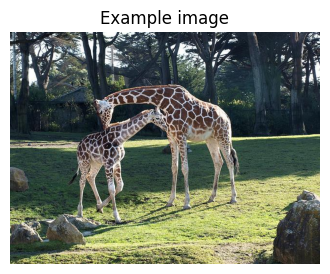

In [6]:
example = dataset_full["train"][0]

print("Keys:", example.keys())
print("Label_A:", example["Label_A"], "-", LABEL_A_NAMES.get(example["Label_A"], "Unknown"))
print("Label_B:", example["Label_B"], "-", LABEL_B_NAMES.get(example["Label_B"], "Unknown"))

if "Caption" in example:
    print("Caption:", example["Caption"])

img = example["Image"]
print("Image type:", type(img))
print("Image mode:", img.mode)
print("Image size:", img.size)

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis("off")
plt.title("Example image")
plt.show()


## 7. Check original label distribution

**Before this cell runs:** we know the dataset structure, but we have not quantified the class distribution.

**After this cell runs:** `original_distribution` shows the count of real and AI-generated images in each split, plus the generator-level `Label_B` distribution. This gives us the baseline distribution that the training notebooks should be aware of.


In [7]:
def build_distribution_table(ds_dict):
    rows = []

    for split in EXPECTED_SPLITS:
        label_a_counts = Counter(ds_dict[split]["Label_A"])
        label_b_counts = Counter(ds_dict[split]["Label_B"])

        for label_a, count in sorted(label_a_counts.items()):
            rows.append({
                "split": split,
                "label_type": "Label_A",
                "label_id": label_a,
                "label_name": LABEL_A_NAMES.get(label_a, "Unknown"),
                "count": count,
            })

        for label_b, count in sorted(label_b_counts.items()):
            rows.append({
                "split": split,
                "label_type": "Label_B",
                "label_id": label_b,
                "label_name": LABEL_B_NAMES.get(label_b, "Unknown"),
                "count": count,
            })

    return pd.DataFrame(rows)


original_distribution = build_distribution_table(dataset_full)
original_distribution


,split,label_type,label_id,label_name,count
0,train,Label_A,0,Real,7000
1,train,Label_A,1,AI-generated,35000
2,train,Label_B,0,Real,7000
3,train,Label_B,1,SD21,7000
4,train,Label_B,2,SDXL,7000
5,train,Label_B,3,SD3,7000
6,train,Label_B,4,DALLE3,7000
7,train,Label_B,5,Midjourney,7000
8,validation,Label_A,0,Real,1500
9,validation,Label_A,1,AI-generated,7500


## 8. Validate label consistency

**Before this cell runs:** we have counts, but we have not checked whether `Label_A` and `Label_B` agree logically.

**After this cell runs:** the notebook verifies that real images have `Label_A = 0` and `Label_B = 0`, while AI-generated images have `Label_A = 1` and one of the five generator labels. This helps catch mislabeled rows or schema misunderstandings before training.


In [8]:
def check_label_consistency(ds_dict):
    problems = []

    for split in EXPECTED_SPLITS:
        for i, row in enumerate(ds_dict[split]):
            label_a = row["Label_A"]
            label_b = row["Label_B"]

            real_ok = (label_a == 0 and label_b == 0)
            ai_ok = (label_a == 1 and label_b in {1, 2, 3, 4, 5})

            if not (real_ok or ai_ok):
                problems.append({
                    "split": split,
                    "index": i,
                    "Label_A": label_a,
                    "Label_B": label_b,
                })

    return pd.DataFrame(problems)


label_problems = check_label_consistency(dataset_full)

if len(label_problems) == 0:
    print("No Label_A / Label_B consistency issues found.")
else:
    print(f"Found {len(label_problems)} label consistency issues.")
    display(label_problems.head(20))


No Label_A / Label_B consistency issues found.


## 9. Preserve the original Hugging Face splits

**Before this cell runs:** `dataset_full` contains the original train/validation/test splits loaded from Hugging Face.

**After this cell runs:** `dataset` points to the same unmodified splits. This makes the handoff to later notebooks simple: use `dataset` for training, validation, and testing, while knowing that no rows were removed or resampled here.


In [9]:
# Keep the original Hugging Face splits exactly as provided.
# We assign this to `dataset` so later notebooks can use one consistent object name.
dataset = dataset_full

for split in EXPECTED_SPLITS:
    print(f"{split}: {len(dataset[split]):,} rows")


train: 42,000 rows
validation: 9,000 rows
test: 45,000 rows


## 10. Confirm the final dataset distribution

**Before this cell runs:** `dataset` has been assigned, but we have not rechecked the distribution of the final handoff object.

**After this cell runs:** `final_distribution` confirms that the final dataset has the same class and generator-level counts as the original Hugging Face splits. This protects us from accidentally running training on a modified object.


In [10]:
final_distribution = build_distribution_table(dataset)
final_distribution


,split,label_type,label_id,label_name,count
0,train,Label_A,0,Real,7000
1,train,Label_A,1,AI-generated,35000
2,train,Label_B,0,Real,7000
3,train,Label_B,1,SD21,7000
4,train,Label_B,2,SDXL,7000
5,train,Label_B,3,SD3,7000
6,train,Label_B,4,DALLE3,7000
7,train,Label_B,5,Midjourney,7000
8,validation,Label_A,0,Real,1500
9,validation,Label_A,1,AI-generated,7500


In [11]:
# Sanity check: because we are no longer downsampling, the final dataset
# should match the original dataset exactly in size and label distribution.

for split in EXPECTED_SPLITS:
    original_len = len(dataset_full[split])
    final_len = len(dataset[split])

    original_label_a = Counter(dataset_full[split]["Label_A"])
    final_label_a = Counter(dataset[split]["Label_A"])

    original_label_b = Counter(dataset_full[split]["Label_B"])
    final_label_b = Counter(dataset[split]["Label_B"])

    print(f"\n--- {split} ---")
    print("Rows:", final_len)
    print("Label_A:", dict(sorted(final_label_a.items())))
    print("Label_B:", dict(sorted(final_label_b.items())))

    assert final_len == original_len, f"{split}: final row count changed."
    assert final_label_a == original_label_a, f"{split}: Label_A distribution changed."
    assert final_label_b == original_label_b, f"{split}: Label_B distribution changed."

print("\nFinal dataset matches the original Hugging Face splits.")



--- train ---
Rows: 42000
Label_A: {0: 7000, 1: 35000}
Label_B: {0: 7000, 1: 7000, 2: 7000, 3: 7000, 4: 7000, 5: 7000}

--- validation ---
Rows: 9000
Label_A: {0: 1500, 1: 7500}
Label_B: {0: 1500, 1: 1500, 2: 1500, 3: 1500, 4: 1500, 5: 1500}

--- test ---
Rows: 45000
Label_A: {0: 7500, 1: 37500}
Label_B: {0: 7500, 1: 7500, 2: 7500, 3: 7500, 4: 7500, 5: 7500}

Final dataset matches the original Hugging Face splits.


## 11. Show random examples from each class

**Before this cell runs:** the dataset has been numerically checked, but we have not visually inspected examples from the final handoff object.

**After this cell runs:** we see random real and AI-generated examples from a chosen split. This helps catch obvious visual issues, wrong columns, corrupted images, or label mismatches that numerical checks may miss.


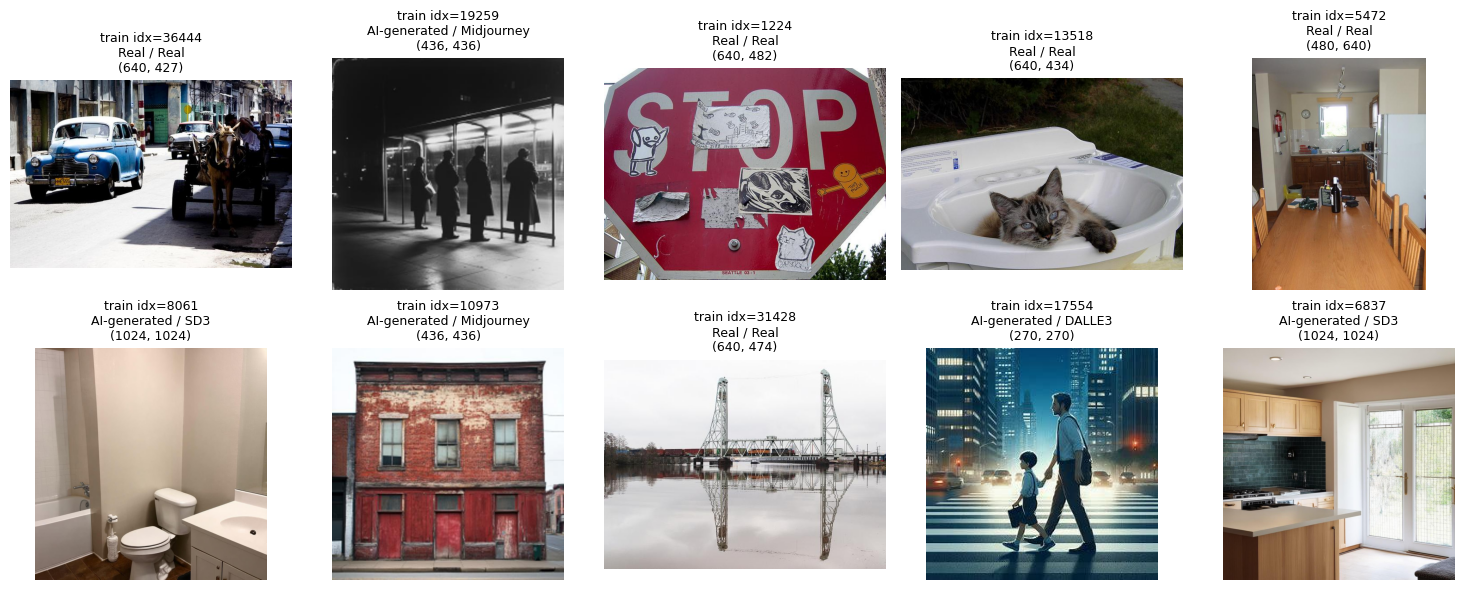

In [12]:
def show_balanced_examples(ds_dict, split="train", n_per_class=5, seed=SEED):
    rng = random.Random(seed)

    real_indices = [i for i, label in enumerate(ds_dict[split]["Label_A"]) if label == 0]
    ai_indices = [i for i, label in enumerate(ds_dict[split]["Label_A"]) if label == 1]

    selected = (
        rng.sample(real_indices, min(n_per_class, len(real_indices))) +
        rng.sample(ai_indices, min(n_per_class, len(ai_indices)))
    )

    rng.shuffle(selected)

    n_cols = 5
    n_rows = int(np.ceil(len(selected) / n_cols))

    plt.figure(figsize=(15, 3 * n_rows))

    for plot_idx, data_idx in enumerate(selected, start=1):
        row = ds_dict[split][data_idx]
        img = row["Image"]

        plt.subplot(n_rows, n_cols, plot_idx)
        plt.imshow(img)
        plt.axis("off")
        plt.title(
            f"{split} idx={data_idx}\n"
            f"{LABEL_A_NAMES[row['Label_A']]} / {LABEL_B_NAMES[row['Label_B']]}\n"
            f"{img.size}",
            fontsize=9,
        )

    plt.tight_layout()
    plt.show()


show_balanced_examples(dataset, split="train", n_per_class=5)
show_balanced_examples(dataset, split="validation", n_per_class=5)
show_balanced_examples(dataset, split="test", n_per_class=5)


## 12. Check image modes

**Before this cell runs:** we have confirmed the final dataset distribution, but we have not verified that all images have compatible color channels.

**After this cell runs:** `mode_df` shows the image modes found in each split. For a CNN or ViT pipeline, we generally want images to be converted to RGB consistently before tensor conversion, even if most or all images are already RGB.


In [13]:
mode_rows = []

for split in EXPECTED_SPLITS:
    print(f"Checking image modes in {split}...")

    mode_counts = Counter()
    for row in dataset[split]:
        mode_counts[row["Image"].mode] += 1

    for mode, count in sorted(mode_counts.items()):
        mode_rows.append({
            "split": split,
            "mode": mode,
            "count": count,
        })

mode_df = pd.DataFrame(mode_rows)
mode_df


Checking image modes in train...
Checking image modes in validation...
Checking image modes in test...


,split,mode,count
0,train,RGB,42000
1,validation,RGB,9000
2,test,RGB,45000


## 13. Check image size and aspect ratio distributions

**Before this cell runs:** the dataset has been validated at the label level, but images may still differ substantially in width, height, or aspect ratio.

**After this cell runs:** `image_meta_df` summarizes image dimensions by split and class. This check matters because image size differences can become a shortcut: a model may learn dataset artifacts instead of learning real visual differences between real and AI-generated images.


In [14]:
image_meta_rows = []

for split in EXPECTED_SPLITS:
    print(f"Collecting image metadata from {split}...")

    for i, row in enumerate(dataset[split]):
        img = row["Image"]
        width, height = img.size

        image_meta_rows.append({
            "split": split,
            "index": i,
            "width": width,
            "height": height,
            "aspect_ratio": width / height,
            "Label_A": row["Label_A"],
            "Label_A_name": LABEL_A_NAMES[row["Label_A"]],
            "Label_B": row["Label_B"],
            "Label_B_name": LABEL_B_NAMES[row["Label_B"]],
        })

image_meta_df = pd.DataFrame(image_meta_rows)

image_meta_df.groupby(["split", "Label_A_name"])[
    ["width", "height", "aspect_ratio"]
].describe()


width                                               \
                           count        mean         std    min    25%    50%   
split      Label_A_name                                                         
test       AI-generated  37500.0  704.508000  306.157550  270.0  436.0  768.0   
           Real           7500.0  576.982667   92.276052  176.0  500.0  640.0   
train      AI-generated  35000.0  704.474971  306.204372  270.0  436.0  768.0   
           Real           7000.0  579.498857   89.959750  156.0  500.0  640.0   
validation AI-generated   7500.0  704.475600  306.215576  270.0  436.0  768.0   
           Real           1500.0  574.447333   92.687201  229.0  500.0  640.0   

                                          height              ...           \
                            75%     max    count        mean  ...      75%   
split      Label_A_name                                       ...            
test       AI-generated  1024.0  1024.0  37500.0  704.508000  ...  1024.00   
           Real           640.0   640.0   7500.0  483.504667  ...   513.00   
train      AI-generated  1024.0  1024.0  35000.0  704.474971  ...  1024.00   
           Real           640.0   640.0   7000.0  482.866571  ...   504.00   
validation AI-generated  1024.0  1024.0   7500.0  704.475600  ...  1024.00   
           Real           640.0   640.0   1500.0  486.521333  ...   521.25   

                                aspect_ratio                                \
                            max        count      mean       std       min   
split      Label_A_name                                                      
test       AI-generated  1024.0      37500.0  1.000000  0.000000  1.000000   
           Real           640.0       7500.0  1.255187  0.349390  0.323437   
train      AI-generated  1024.0      35000.0  1.000000  0.000000  1.000000   
           Real           640.0       7000.0  1.261800  0.347319  0.243750   
validation AI-generated  1024.0       7500.0  1.000000  0.000000  1.000000   
           Real           640.0       1500.0  1.243157  0.350267  0.494000   

                                                                 
                              25%       50%       75%       max  
split      Label_A_name                                          
test       AI-generated  1.000000  1.000000  1.000000  1.000000  
           Real          1.000000  1.333333  1.498829  4.025157  
train      AI-generated  1.000000  1.000000  1.000000  1.000000  
           Real          1.000000  1.333333  1.498829  5.000000  
validation AI-generated  1.000000  1.000000  1.000000  1.000000  
           Real          0.937484  1.333333  1.498829  2.882883  

[6 rows x 24 columns]

/tmp/ipykernel_3339/3868161809.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=["Real", "AI-generated"])


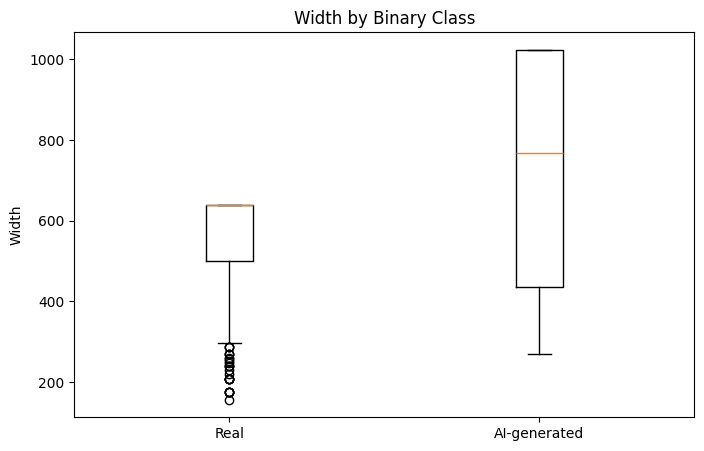

/tmp/ipykernel_3339/3868161809.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=["Real", "AI-generated"])


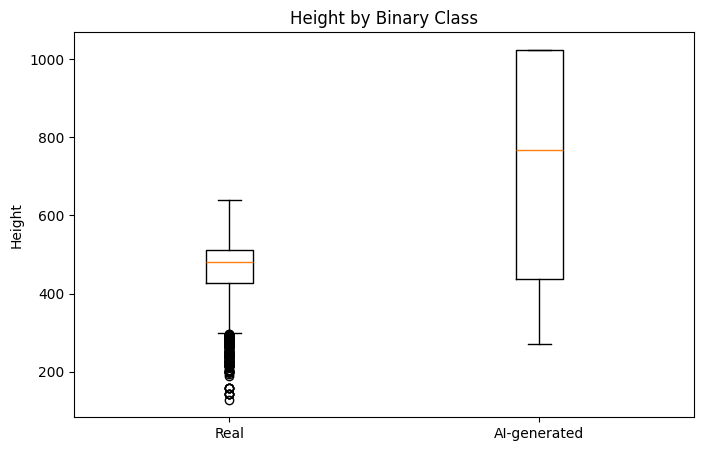

/tmp/ipykernel_3339/3868161809.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=["Real", "AI-generated"])


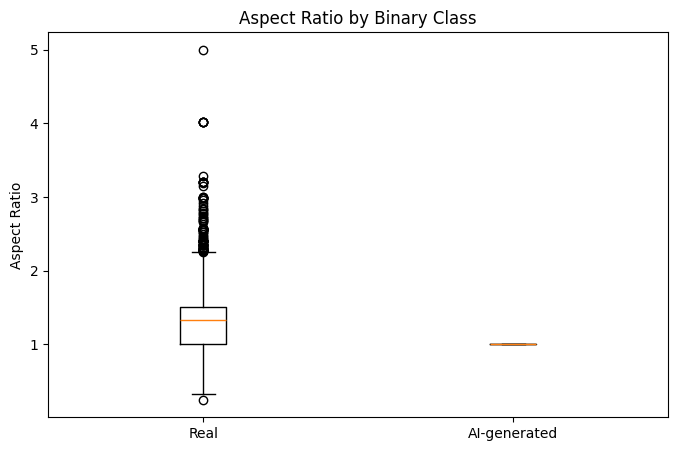

In [15]:
# Plot each metric separately to make the distributions easier to inspect.

for metric in ["width", "height", "aspect_ratio"]:
    plt.figure(figsize=(8, 5))

    groups = [
        image_meta_df.loc[image_meta_df["Label_A_name"] == "Real", metric],
        image_meta_df.loc[image_meta_df["Label_A_name"] == "AI-generated", metric],
    ]

    plt.boxplot(groups, labels=["Real", "AI-generated"])
    plt.title(f"{metric.replace('_', ' ').title()} by Binary Class")
    plt.ylabel(metric.replace("_", " ").title())
    plt.show()


## 14. Compare preprocessing options

**Before this cell runs:** we know images have different sizes, but we have not checked how common preprocessing strategies affect the images.

**After this cell runs:** we visually compare direct resize, resize plus center crop, and resize with padding. This helps decide whether preprocessing is introducing distortions or removing important content. The training notebooks can then use the chosen preprocessing consistently.


In [16]:
transform_resize = transforms.Resize((224, 224))

transform_center_crop = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
])


def resize_with_padding(image, size=224, fill=0):
    """Resize image while preserving aspect ratio, then pad to a square.

    This avoids stretching the image, but it introduces padding.
    Padding can also become a visual artifact, so it should be inspected.
    """

    image = image.convert("RGB")
    width, height = image.size

    scale = size / max(width, height)
    new_width = int(round(width * scale))
    new_height = int(round(height * scale))

    resized = F.resize(image, (new_height, new_width))

    pad_width = size - new_width
    pad_height = size - new_height

    padding = (
        pad_width // 2,
        pad_height // 2,
        pad_width - (pad_width // 2),
        pad_height - (pad_height // 2),
    )

    return F.pad(resized, padding, fill=fill)


def show_preprocessing_comparison(ds_dict, split="train", n=6, seed=SEED):
    rng = random.Random(seed)
    indices = rng.sample(range(len(ds_dict[split])), n)

    for data_idx in indices:
        row = ds_dict[split][data_idx]
        img = row["Image"].convert("RGB")

        variants = [
            ("Original", img),
            ("Resize only", transform_resize(img)),
            ("Resize + CenterCrop", transform_center_crop(img)),
            ("Resize + Padding", resize_with_padding(img)),
        ]

        plt.figure(figsize=(16, 4))

        for plot_idx, (title, variant_img) in enumerate(variants, start=1):
            plt.subplot(1, 4, plot_idx)
            plt.imshow(variant_img)
            plt.axis("off")
            plt.title(
                f"{title}\n"
                f"{variant_img.size}\n"
                f"{LABEL_A_NAMES[row['Label_A']]} / {LABEL_B_NAMES[row['Label_B']]}",
                fontsize=9,
            )

        plt.tight_layout()
        plt.show()


show_preprocessing_comparison(dataset, split="train", n=6)


Output hidden; open in https://colab.research.google.com to view.

## 15. Check exact duplicate leakage across splits

**Before this cell runs:** we have checked labels and image metadata, but we have not checked whether the same image appears in multiple splits.

**After this cell runs:** `duplicate_summary_df` reports exact duplicate groups within each split and exact image overlaps across train/validation/test. Cross-split duplicates are especially important because they can inflate validation or test performance.


In [17]:
def exact_image_hash(img):
    """Hash image pixels after converting to RGB.

    This finds exact pixel duplicates after RGB conversion.
    It will not catch near-duplicates, crops, resized copies, or compressed variants.
    """

    img = img.convert("RGB")
    return hashlib.md5(img.tobytes()).hexdigest()


split_hashes = {
    split: defaultdict(list)
    for split in EXPECTED_SPLITS
}

for split in EXPECTED_SPLITS:
    print(f"Hashing {split}...")
    for idx, row in enumerate(dataset[split]):
        h = exact_image_hash(row["Image"])
        split_hashes[split][h].append(idx)


duplicate_rows = []

# Within-split duplicate checks.
for split in EXPECTED_SPLITS:
    duplicate_groups = {
        h: indices
        for h, indices in split_hashes[split].items()
        if len(indices) > 1
    }

    duplicate_rows.append({
        "check_type": "within_split",
        "split_pair": split,
        "duplicate_hash_groups": len(duplicate_groups),
        "images_involved": sum(len(indices) for indices in duplicate_groups.values()),
    })

# Cross-split leakage checks.
cross_split_overlaps = {}

for split_1, split_2 in [
    ("train", "validation"),
    ("train", "test"),
    ("validation", "test"),
]:
    overlap_hashes = set(split_hashes[split_1].keys()) & set(split_hashes[split_2].keys())
    cross_split_overlaps[(split_1, split_2)] = overlap_hashes

    images_1 = sum(len(split_hashes[split_1][h]) for h in overlap_hashes)
    images_2 = sum(len(split_hashes[split_2][h]) for h in overlap_hashes)

    duplicate_rows.append({
        "check_type": "cross_split",
        "split_pair": f"{split_1} / {split_2}",
        "duplicate_hash_groups": len(overlap_hashes),
        "images_involved": images_1 + images_2,
    })

duplicate_summary_df = pd.DataFrame(duplicate_rows)
duplicate_summary_df


Hashing train...
Hashing validation...
Hashing test...


,check_type,split_pair,duplicate_hash_groups,images_involved
0,within_split,train,15,46
1,within_split,validation,2,4
2,within_split,test,4,8
3,cross_split,train / validation,7,29
4,cross_split,train / test,8,32
5,cross_split,validation / test,3,7


## 16. Display exact cross-split duplicates if any exist

**Before this cell runs:** the duplicate summary tells us whether cross-split overlap exists, but not what those images look like.

**After this cell runs:** if exact overlaps exist, the notebook displays examples side by side. If no overlaps exist, it simply prints that no exact duplicate pairs were found.


Showing up to 5 exact duplicate pairs from train / validation.


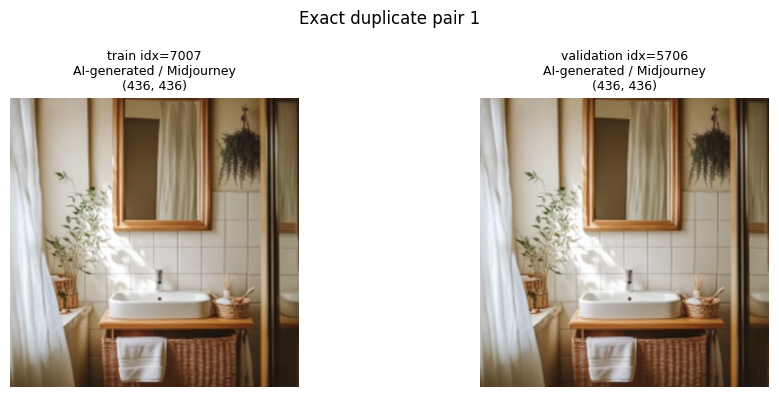

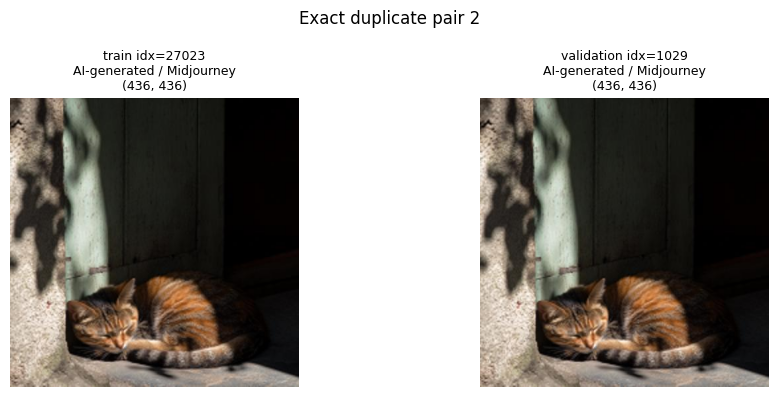

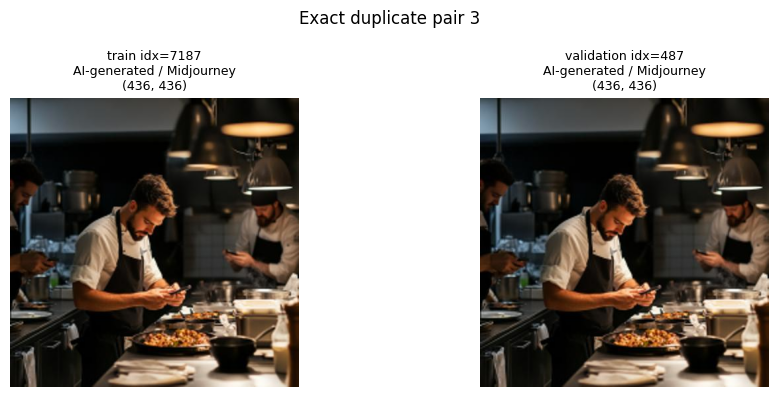

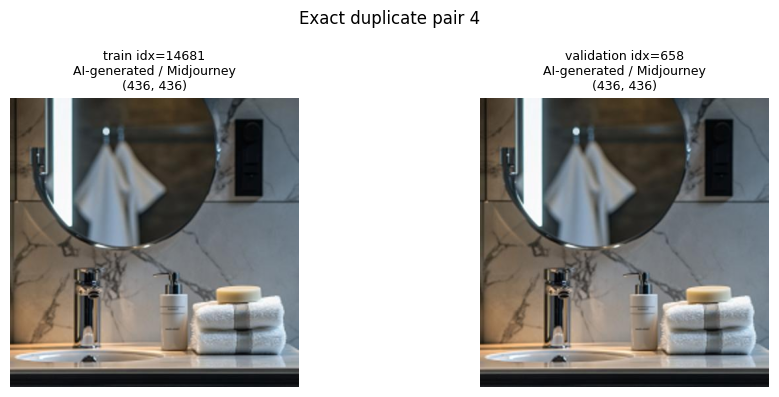

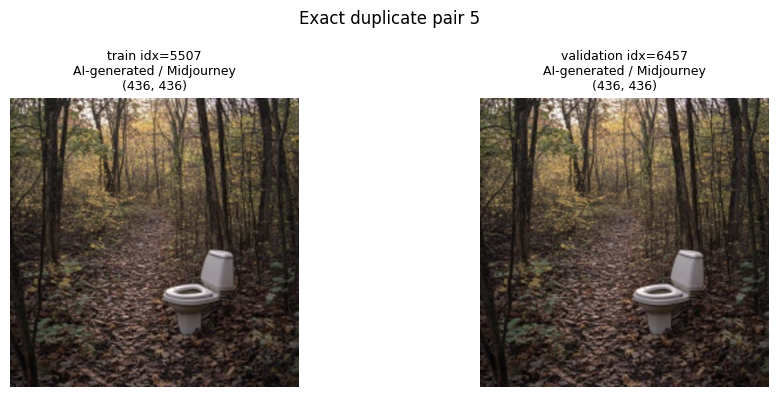

Showing up to 5 exact duplicate pairs from train / test.


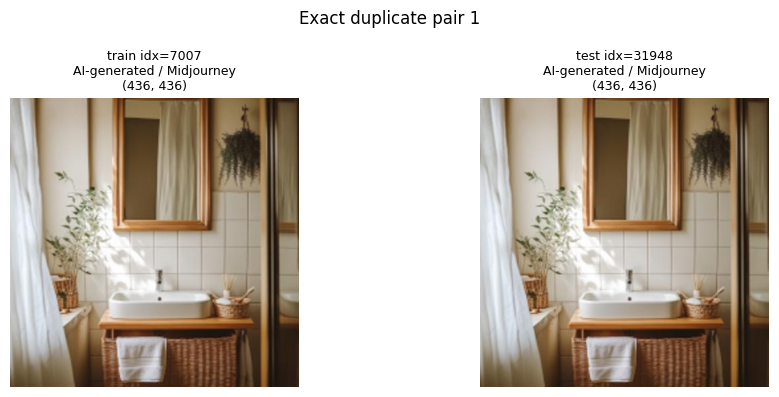

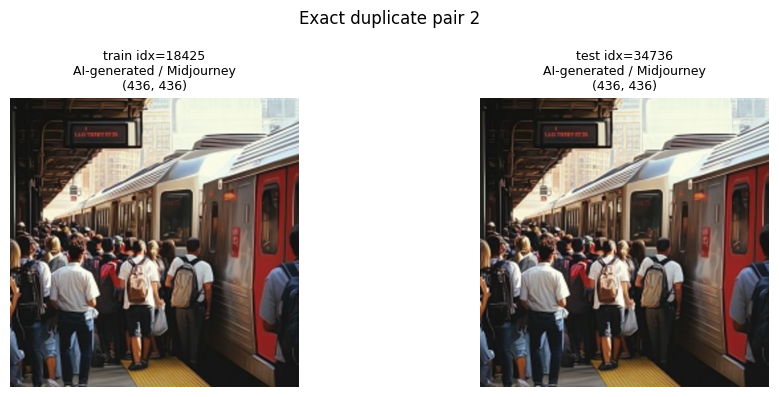

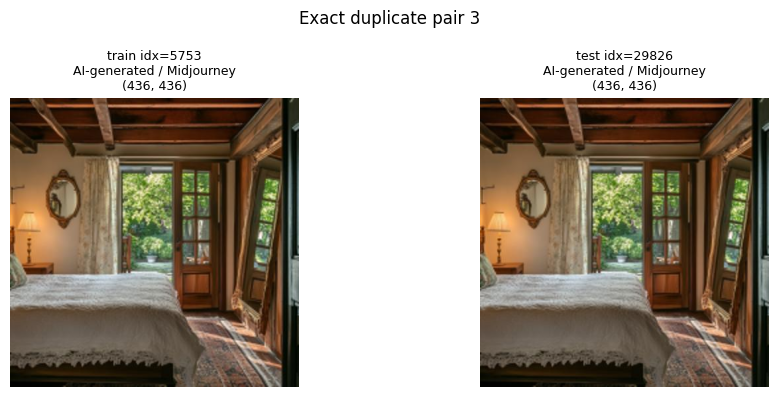

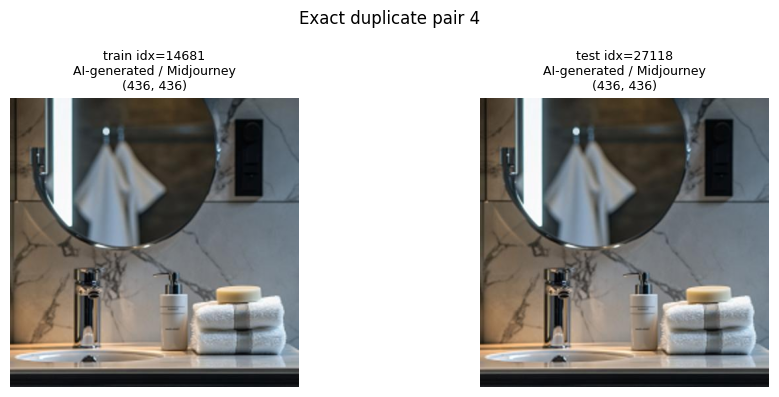

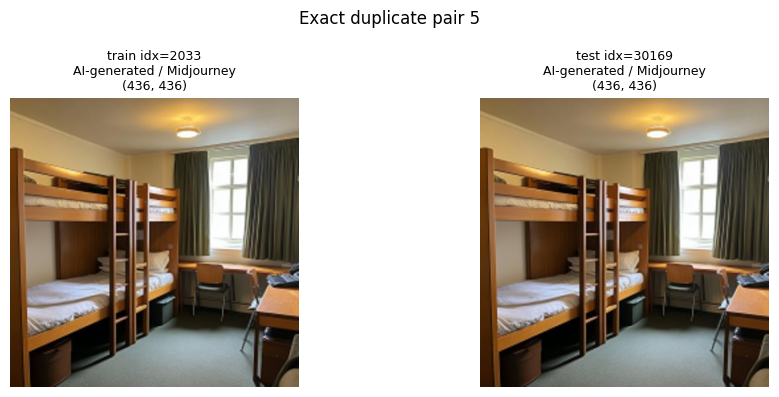

Showing up to 5 exact duplicate pairs from validation / test.


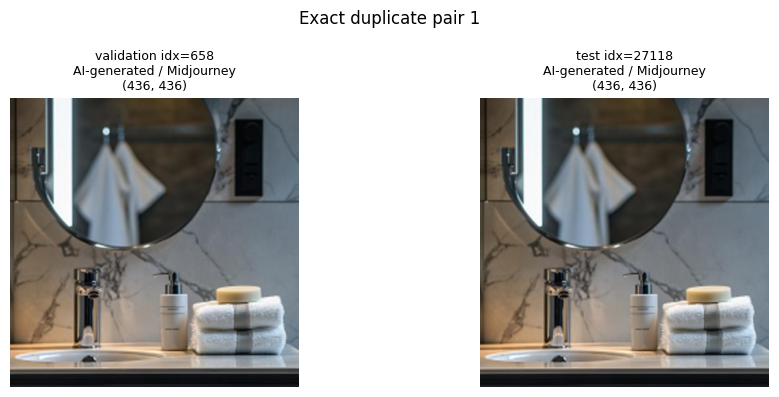

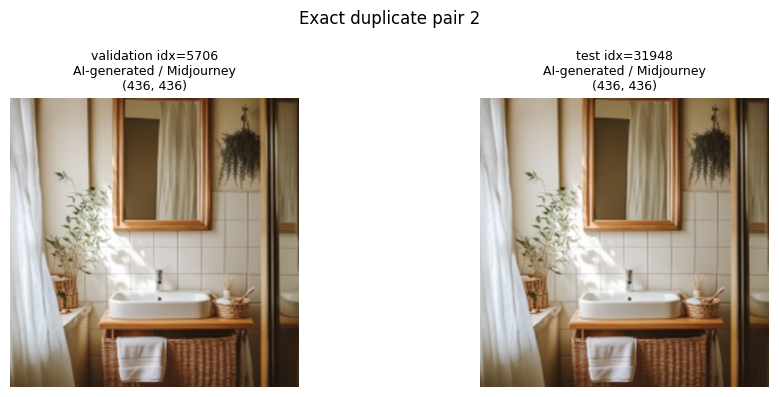

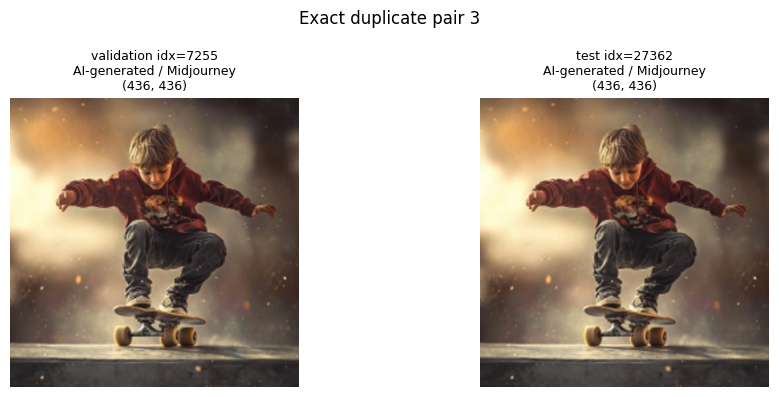

In [18]:
def show_cross_split_duplicates(ds_dict, split_hashes, split_1, split_2, max_pairs=5):
    overlap_hashes = list(set(split_hashes[split_1].keys()) & set(split_hashes[split_2].keys()))

    if len(overlap_hashes) == 0:
        print(f"No exact duplicates found between {split_1} and {split_2}.")
        return

    print(f"Showing up to {max_pairs} exact duplicate pairs from {split_1} / {split_2}.")

    for pair_number, h in enumerate(overlap_hashes[:max_pairs], start=1):
        idx_1 = split_hashes[split_1][h][0]
        idx_2 = split_hashes[split_2][h][0]

        row_1 = ds_dict[split_1][idx_1]
        row_2 = ds_dict[split_2][idx_2]

        plt.figure(figsize=(10, 4))

        for plot_idx, (split_name, idx, row) in enumerate([
            (split_1, idx_1, row_1),
            (split_2, idx_2, row_2),
        ], start=1):
            img = row["Image"]

            plt.subplot(1, 2, plot_idx)
            plt.imshow(img)
            plt.axis("off")
            plt.title(
                f"{split_name} idx={idx}\n"
                f"{LABEL_A_NAMES[row['Label_A']]} / {LABEL_B_NAMES[row['Label_B']]}\n"
                f"{img.size}",
                fontsize=9,
            )

        plt.suptitle(f"Exact duplicate pair {pair_number}")
        plt.tight_layout()
        plt.show()


show_cross_split_duplicates(dataset, split_hashes, "train", "validation", max_pairs=5)
show_cross_split_duplicates(dataset, split_hashes, "train", "test", max_pairs=5)
show_cross_split_duplicates(dataset, split_hashes, "validation", "test", max_pairs=5)


## 17. Final handoff object for training notebooks

**Before this cell runs:** all checks have been completed, but it may not be obvious which dataset object should be used next.

**After this cell runs:** the notebook prints the final split sizes and confirms that `dataset` is the original, unmodified dataset to pass into the model training notebooks. `dataset_full` is still available as the original loaded object, but it should be identical to `dataset` in this notebook.


In [19]:
print("Use `dataset` for training notebooks.")
print("`dataset_full` is also available and should match `dataset` exactly in this notebook.")
print()

for split in EXPECTED_SPLITS:
    counts = Counter(dataset[split]["Label_A"])
    print(
        f"{split}: {len(dataset[split]):,} rows "
        f"({counts[0]:,} real / {counts[1]:,} AI-generated)"
    )


Use `dataset` for training notebooks.
`dataset_full` is also available and should match `dataset` exactly in this notebook.

train: 42,000 rows (7,000 real / 35,000 AI-generated)
validation: 9,000 rows (1,500 real / 7,500 AI-generated)
test: 45,000 rows (7,500 real / 37,500 AI-generated)
